Jennifer Kelley - 3/4/2026
# Week 8 Assignment


## Story 1 -- Predicting Car Resale Prices
You are a data analyst working for a company that specializes in predicting car resale values. Your goal is to build a predictive model for the resale price of used cars based on key features.  
The dataset includes the following variables:
- Mileage (miles_driven) – The total miles driven by the car.
- Car Age (age) – The number of years since the car was manufactured.
- Engine Size (engine_size) – The engine capacity in liters (e.g., 1.5L, 2.0L).

To begin, we simulate some data. The resale price of the car follows the formula:

$price = (30000 - miles\_driven \times 0.05) + (engine\_size \times 4000) - (age \times 1500)$

You will use the following code for the data generation process:

In [32]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate random data
n = 200
miles_driven = np.random.uniform(5000, 150000, n) # Miles driven between 5,000 and 150,000
age = np.random.randint(1, 21, n)                 # Age between 1 and 20 years
engine_size = np.random.uniform(1.2, 4.0, n)      # Engine size between 1.2L and 4.0L

# Compute price with some random noise
price = (30000 - miles_driven * 0.05) + (engine_size * 4000) - (age * 1500) + np.random.normal(0, 2000, n)

# Create DataFrame
df = pd.DataFrame({'miles_driven': miles_driven, 'age': age, 'engine_size': engine_size, 'price': price})

Perform Exploratory Data Analysis (EDA). Fit an Ordinary Least Squares (OLS) regression model to predict the price based on miles_driven, age, and engine_size. Interpret. Use each of the model diagnostic tools, -Actual vs. Predicted values, Q-Q Plot, and Residual analysis. Interpret.

In [33]:
from sklearn.model_selection import train_test_split

independant = df[['miles_driven', 'age', 'engine_size']]
dependant = df['price']
indep_train, indep_test, dep_train, dep_test = train_test_split(independant, dependant, test_size=0.2, random_state=24)

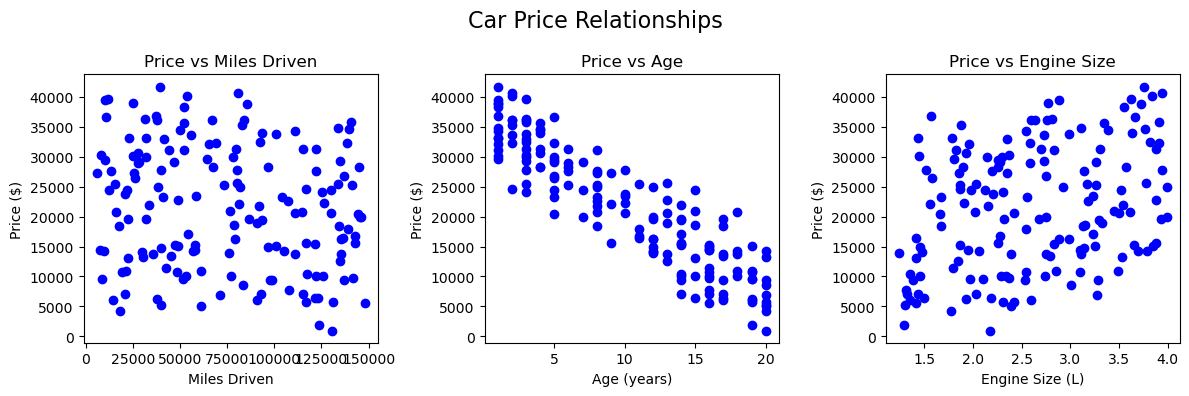

In [34]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

axes[0].scatter(indep_train['miles_driven'], dep_train, color='blue')
axes[0].set_title('Price vs Miles Driven')
axes[0].set_xlabel('Miles Driven')
axes[0].set_ylabel('Price ($)')

axes[1].scatter(indep_train['age'], dep_train, color='blue')
axes[1].set_title('Price vs Age')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Price ($)')

axes[2].scatter(indep_train['engine_size'], dep_train, color='blue')
axes[2].set_title('Price vs Engine Size')
axes[2].set_xlabel('Engine Size (L)')
axes[2].set_ylabel('Price ($)')

fig.suptitle('Car Price Relationships', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 1])

plt.show()

In [35]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

model = sm.OLS(dep_train, indep_train).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.907
Model:                            OLS   Adj. R-squared (uncentered):              0.905
Method:                 Least Squares   F-statistic:                              509.5
Date:                Fri, 06 Mar 2026   Prob (F-statistic):                    1.15e-80
Time:                        12:17:08   Log-Likelihood:                         -1649.6
No. Observations:                 160   AIC:                                      3305.
Df Residuals:                     157   BIC:                                      3314.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

### Interpretation
#### OLS Reression Results
An **Uncentered R‑squared** of $0.907$ and **Adjusted R‑squared** of $0.905$ indicate the model explains most of the variation in the dependent variable when the regression is run without an intercept.

The **F‑statistic**, $509.5$, with a **Probability** of $1.15e‑80$ shows the set of predictors jointly explains variation in price far better than a model with no predictors.

A high **Log-Likelihood** value of $-1649.6$ indicates the model provides a strong fit to the data.

#### Coefficients
**miles_driven** ($0.0242$) For each additional mile driven, the model predicts the price will increase by $\$0.0242$ on average. The p-value is $0.046$, which is just under the 0.05 cutoff, so it is borderline statistically significant. The 95% confidence interval runs from $0.000$ to $0.048$, so the true effect could be very small or twice the estimated size.

**age** ($1018.5845$) For each year in age, the model predicts the price will decrease by $\$1,018.6$ on average. The p-value is effectively zero, so this is a strong, statistically significant effect. The 95% confidence interval, $−1,185.256$ to $−851.913$, shows the decrease is consistently large.

**engine_size** ($10,910$) For each liter in engine_size, the model predicts the price will increase about $\$10,910$ on average. This effect is also highly statistically significant (very small p-value) and the 95% confidence interval is roughly $10,000$ to $11,800$, so the positive effect is large and precise.

#### Diagnostics 
A larger **Omnibus** equalling $7.397$, with an **Omnibus Probability** less than $0.05$ ($0.025$) suggests that residuals are not normally distributed. However, **Jarque‑Bera**, $3.577$, contradicts this with a **JB Probability** of $0.167$, larger than $0.05$, implying statistical signifigance. 

A **Durbin‑Watson** of $1.806$ is close to $2$, so there is no strong evidence of autocorrelation in residuals.

The **Kurtosis** is $2.280$ and **Skew** is $0.069$ meaning residuals are slightly platykurtic (flatter) and nearly symmetric.

There is a very large **Condition Number**, $6.74e+04$ suggesting that some predictors may be highly correlated. There may be some multicollinearity or scaling issues among predictors.

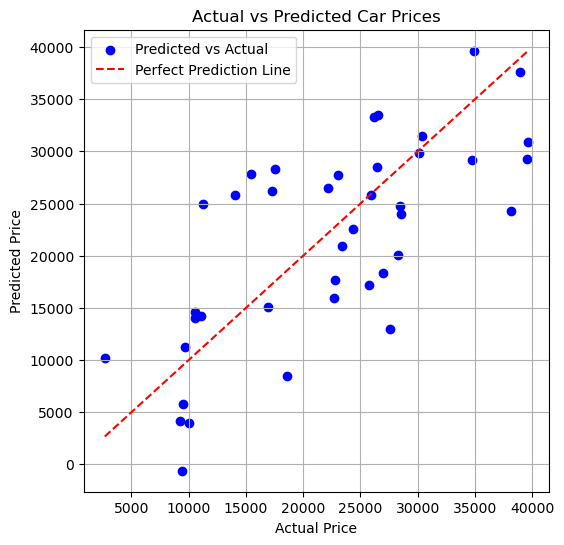

In [36]:
dep_pred = model.predict(indep_test)
plt.figure(figsize=(6,6))

plt.scatter(dep_test, dep_pred, color='blue', label='Predicted vs Actual')
plt.plot([dep_test.min(), dep_test.max()], [dep_test.min(), dep_test.max()], color='red', linestyle='--', label='Perfect Prediction Line')
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid()
plt.show()

### Actual vs. Predicted Diagnostic Interpretation
The points seem to center arount the prediction line, suggesting that the regression model is performing as expected.

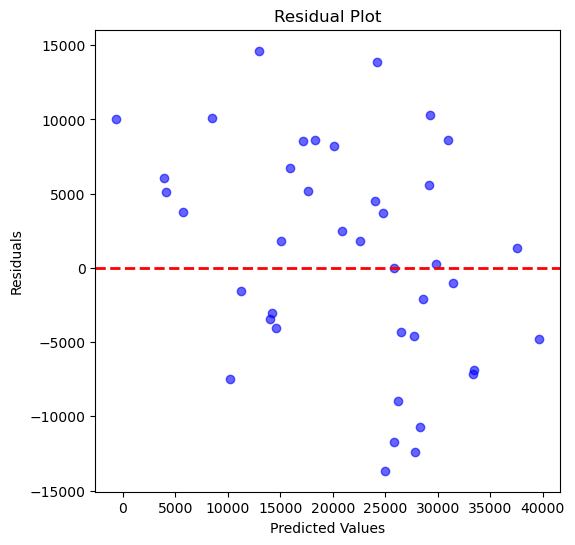

In [37]:
residuals = dep_test - dep_pred

plt.figure(figsize=(6, 6))
plt.scatter(dep_pred, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

###  Residual Analysis Diagnostic Interpretation
The points seem to trend downward suggesting non-linearity, heteroscedasticity, or autocorrelation. However, in this context, in combination with Omnibus and it's p-value I would say there is likely an autocorrelation issue.

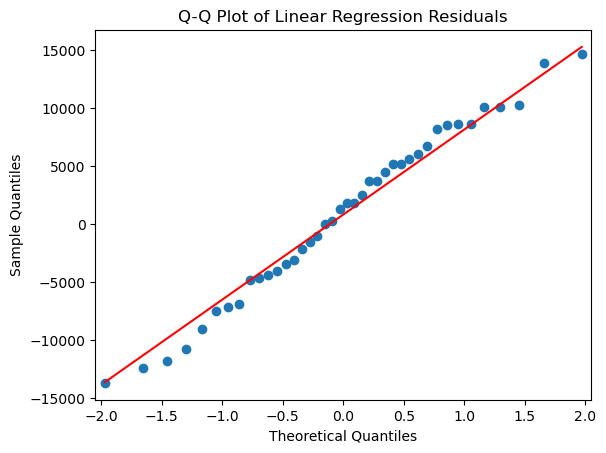

In [38]:
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Linear Regression Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

###  Q-Q Plot Diagnostic Interpretation
The residuals do not deviate largely from the line, suggusting the generally follow a normal distribution.